In [2]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import pingouin as pg

# 머신러닝 
from sklearn.model_selection import train_test_split

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df = pd.read_csv('./data/merged_data.csv')

In [4]:
df2 = df.copy()

In [5]:
# review_score 컬럼 결측치 제거
print(f"제거 전 데이터 개수: {len(df2)}")
df2 = df2.dropna(subset=['review_score']).reset_index()
print(f"제거 후 데이터 개수: {len(df2)}")

제거 전 데이터 개수: 96432
제거 후 데이터 개수: 95786


In [6]:
# 파생 컬럼 생성
df2['order_purchase_timestamp'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['order_delivered_customer_date'] = pd.to_datetime(df2['order_delivered_customer_date'])
df2['order_estimated_delivery_date'] = pd.to_datetime(df2['order_estimated_delivery_date'])
df2['order_approved_at'] = pd.to_datetime(df2['order_approved_at'])
df2['order_delivered_carrier_date'] = pd.to_datetime(df2['order_delivered_carrier_date'])

# 주문 시점의 요일 정보 추가
df2['order_purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek
df2['order_purchase_dayofweek'] = df2['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
# 요일 순서 정의 
weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# 데이터를 범주형(Categorical)으로 변환하여 순서 부여
# 이렇게 하면 groupby를 해도 이 순서가 유지됨
df2['order_purchase_dayofweek'] = pd.Categorical(df2['order_purchase_dayofweek'], 
                                                categories=weekday_order, 
                                                ordered=True)

# 주문 시점의 월 정보 추가
df2['order_purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['order_purchase_month'] = df2['order_purchase_month'].astype('category')
df2['order_purchase_month'] = df2['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df2['order_purchase_month'] = df2['order_purchase_month'].cat.codes
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)
df2['order_purchase_month'] = df2['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)

# 주문 시점의 연도 정보 추가
df2['order_purchase_year'] = df2['order_purchase_timestamp'].dt.year
df2['order_purchase_year'] = df2['order_purchase_year'].astype(int)

df2.info()
df2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_zip_code_prefix       95786 non-null  int64         
 10  customer_city                  95786 non-null  str           
 11  customer_state            

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,total_items_count,product_id,seller_id,price,freight_value,review_score,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month,order_purchase_year
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,4.0,housewares,9350,maua,SP,-23.680862,-46.444311,monday,10,2017
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.186877,-44.540232,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,4.0,perfumery,31570,belo horizonte,SP,-19.807885,-43.980818,tuesday,7,2018
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,5.0,auto,14840,guariba,SP,-21.363473,-48.229588,wednesday,8,2018
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774002,-35.270976,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,5.0,pet_shop,31842,belo horizonte,MG,-19.836871,-43.923241,saturday,11,2017
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676257,-46.514580,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,5.0,stationery,8752,mogi das cruzes,SP,-23.541525,-46.262148,tuesday,2,2018
5,5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,-23.553601,-50.549812,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,147.90,27.36,4.0,auto,7112,guarulhos,SP,-23.469087,-46.515649,sunday,7,2017
6,6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,-22.805674,-43.423059,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,59.99,15.17,5.0,auto,12940,atibaia,SP,-23.114661,-46.553045,tuesday,5,2017
7,7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,-27.421769,-52.675022,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,19.90,16.05,1.0,furniture_decor,13720,sao jose do rio pardo,SP,-21.584558,-46.942793,monday,1,2017
8,8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,-23.474639,-47.467220,1,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,149.99,19.77,5.0,office_furniture,8577,itaquaquecetuba,SP,-23.486138,-46.367107,saturday,7

In [7]:
### 승인 소요 일수 계산 (order_approved_at - order_purchase_timestamp)
df2['approved_days'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['approved_days'] = df2['approved_days'].astype(int)

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df2['dispatch_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['dispatch_days'] = df2['dispatch_days'].astype(int)

### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['delivery_days'] = df2['delivery_days'].astype(int)

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df2['expected_delivery_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['expected_delivery_days'] = df2['expected_delivery_days'].astype(int)

### 지연 일수 계산 (order_delivered_customer_date - order_estimated_delivery_date)
# 지연된 것이 양수
df2['delay_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.total_seconds() / 86400
df2['delay_days'] = df2['delay_days'].round(1)
df2['delay_days_int'] = df2['delay_days'].astype(int)

### 지연 여부 (0 또는 1)
df2['is_delayed'] = (df2['delay_days'] > 0).astype(int)

In [8]:
df2.head()

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,total_items_count,product_id,seller_id,price,freight_value,review_score,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,4.0,housewares,9350,maua,SP,-23.680862,-46.444311,monday,10,2017,0,2,8,15,-7.1,-7,0
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.186877,-44.540232,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,4.0,perfumery,31570,belo horizonte,SP,-19.807885,-43.980818,tuesday,7,2018,1,1,13,19,-5.4,-5,0
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,5.0,auto,14840,guariba,SP,-21.363473,-48.229588,wednesday,8,2018,0,0,9,26,-17.2,-17,0
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774002,-35.270976,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,5.0,pet_shop,31842,belo horizonte,MG,-19.836871,-43.923241,saturday,11,2017,0,3,13,26,-13.0,-13,0
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676257,-46.514580,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,5.0,stationery,8752,mogi das cruzes,SP,-23.541525,-46.262148,tuesday,2,2018,0,0,2,12,-9.2,-9,0


In [9]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95786 entries, 0 to 95785
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95786 non-null  int64         
 1   order_id                       95786 non-null  str           
 2   customer_id                    95786 non-null  str           
 3   order_purchase_timestamp       95786 non-null  datetime64[us]
 4   order_approved_at              95786 non-null  datetime64[us]
 5   order_delivered_carrier_date   95786 non-null  datetime64[us]
 6   order_delivered_customer_date  95786 non-null  datetime64[us]
 7   order_estimated_delivery_date  95786 non-null  datetime64[us]
 8   customer_unique_id             95786 non-null  str           
 9   customer_zip_code_prefix       95786 non-null  int64         
 10  customer_city                  95786 non-null  str           
 11  customer_state            

In [10]:
df2.isna().sum()

index                               0
order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
customer_lat                      263
customer_lng                      263
total_items_count                   0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
review_score                        0
product_category_name_english    1370
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
seller_lat                        216
seller_lng                        216
order_purcha

### 이상치 처리
#### 출고일 < 0 행 제거

In [11]:
# 이상치 처리 
data = df2[df2['dispatch_days'] < 0].copy() 
data

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,total_items_count,product_id,seller_id,price,freight_value,review_score,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month,order_purchase_year,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
24963,25111,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,faed38109bbf7da6f035630d92a49a27,4041,sao paulo,SP,-23.601417,-46.644406,1,9070fbe936bd54b8a72e0ffe4a6a2564,89de2d6f23e9746ff309705b23581faa,40.0,14.58,5.0,books_technical,86060,londrina,PR,-23.312250,-51.175615,monday,7,2018,0,-171,7,21,-14.2,-14,0
80252,80782,4021cd7611d6d9ce5ffcd24817fc374f,ac27243bffbc9c58eb62adfb58c71488,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,2018-08-30,216dc3bc64c10494ca97500c2a6b658f,13337,indaiatuba,SP,-23.062398,-47.169389,1,98e55bdc6487be7b8c32b0eb689dcb8a,4a23adac87cf538689fa600d976f78b2,135.0,8.21,4.0,furniture_decor,4537,sao paulo,SP,-23.592841,-46.676990,saturday,8,2018,0,-4,10,11,-0.8,0,0


In [12]:
print(f"이상치 제거 전 행 수 : {len(df2)}")
df2 = df2[df2['dispatch_days'] >= 0].copy()
print(f"이상치 제거 후 행 수 : {len(df2)}")

이상치 제거 전 행 수 : 95786
이상치 제거 후 행 수 : 95784


In [13]:
# delay_days를 카테고리화
def delay_days_cat(x):
    if x < 0:
         return '조기'
    elif x == 0:
         return '정시'
    elif x <= 3: 
        return '1-3일 지연'
    elif x <= 6: 
        return '4-6일 지연'
    elif x <= 9:
        return '7-9일 지연'
    else: 
        return '10일 이상 지연'

df2['delay_days_cat'] = df2['delay_days'].apply(delay_days_cat)

In [14]:
df2['delay_days_cat'].value_counts()

delay_days_cat
조기           88010
1-3일 지연       2591
10일 이상 지연     2435
4-6일 지연       1374
7-9일 지연       1199
정시             175
Name: count, dtype: int64

In [15]:
df2.info()

<class 'pandas.DataFrame'>
Index: 95784 entries, 0 to 95785
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95784 non-null  int64         
 1   order_id                       95784 non-null  str           
 2   customer_id                    95784 non-null  str           
 3   order_purchase_timestamp       95784 non-null  datetime64[us]
 4   order_approved_at              95784 non-null  datetime64[us]
 5   order_delivered_carrier_date   95784 non-null  datetime64[us]
 6   order_delivered_customer_date  95784 non-null  datetime64[us]
 7   order_estimated_delivery_date  95784 non-null  datetime64[us]
 8   customer_unique_id             95784 non-null  str           
 9   customer_zip_code_prefix       95784 non-null  int64         
 10  customer_city                  95784 non-null  str           
 11  customer_state                 

In [16]:
df_geolocation = pd.read_csv('./data/olist_geolocation_dataset.csv')
# geolocation 데이터는 중복된 지리 정보가 많으므로, geolocation_zip_code_prefix를 기준으로 그룹화하여 고유한 지리 정보만 남깁니다.
df_geo_unique = df_geolocation.groupby('geolocation_zip_code_prefix').agg({
'geolocation_lat': 'mean',
'geolocation_lng': 'mean'
}).reset_index()

delete_columns = ['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
df2 = df2.drop(delete_columns, axis=1)

df2 = pd.merge(df2, df_geo_unique, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df2 = df2.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}).drop('geolocation_zip_code_prefix', axis=1)
df2 = pd.merge(df2, df_geo_unique, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
df2 = df2.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}).drop('geolocation_zip_code_prefix', axis=1)

In [17]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   index                          95784 non-null  int64         
 1   order_id                       95784 non-null  str           
 2   customer_id                    95784 non-null  str           
 3   order_purchase_timestamp       95784 non-null  datetime64[us]
 4   order_approved_at              95784 non-null  datetime64[us]
 5   order_delivered_carrier_date   95784 non-null  datetime64[us]
 6   order_delivered_customer_date  95784 non-null  datetime64[us]
 7   order_estimated_delivery_date  95784 non-null  datetime64[us]
 8   customer_unique_id             95784 non-null  str           
 9   customer_zip_code_prefix       95784 non-null  int64         
 10  customer_city                  95784 non-null  str           
 11  customer_state            

In [18]:
df2.isna().sum()

index                               0
order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_items_count                   0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
review_score                        0
product_category_name_english    1370
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
order_purchase_dayofweek            0
order_purchase_month                0
order_purchase_year                 0
approved_days                       0
dispatch_day

In [19]:
cols = df2.columns
cols

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'total_items_count', 'product_id', 'seller_id',
       'price', 'freight_value', 'review_score',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'order_purchase_year', 'approved_days',
       'dispatch_days', 'delivery_days', 'expected_delivery_days',
       'delay_days', 'delay_days_int', 'is_delayed', 'delay_days_cat',
       'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng'],
      dtype='str')

In [20]:
delete_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date',
                'order_estimated_delivery_date','product_id','order_purchase_year', 'delay_days_int', 'delay_days_cat']
df2 = df2.drop(delete_cols, axis=1)
df2['delay_days'] = df2['delay_days'].astype(int)

In [21]:
df2.rename(columns={'product_category_name_english': 'category'}, inplace=True)

In [22]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     95784 non-null  int64   
 1   order_id                  95784 non-null  str     
 2   customer_id               95784 non-null  str     
 3   customer_unique_id        95784 non-null  str     
 4   customer_zip_code_prefix  95784 non-null  int64   
 5   customer_city             95784 non-null  str     
 6   customer_state            95784 non-null  str     
 7   total_items_count         95784 non-null  int64   
 8   seller_id                 95784 non-null  str     
 9   price                     95784 non-null  float64 
 10  freight_value             95784 non-null  float64 
 11  review_score              95784 non-null  float64 
 12  category                  94414 non-null  str     
 13  seller_zip_code_prefix    95784 non-null  int64   
 14  s

In [23]:
def map_to_main_category(cat):
    # 대분류 매핑 사전 정의
    mapping = {
        # 1. 홈 & 리빙 (Home & Living)
        'bed_bath_table': 'Home & Living', 'furniture_decor': 'Home & Living', 
        'housewares': 'Home & Living', 'office_furniture': 'Home & Living',
        'home_confort': 'Home & Living', 'home_comfort_2': 'Home & Living',
        'furniture_living_room': 'Home & Living', 'furniture_bedroom': 'Home & Living',
        'furniture_mattress_and_upholstery': 'Home & Living', 'home_appliances': 'Home & Living',
        'home_appliances_2': 'Home & Living', 'small_appliances': 'Home & Living',
        'small_appliances_home_oven_and_coffee': 'Home & Living', 'air_conditioning': 'Home & Living',
        'kitchen_dining_laundry_garden_furniture': 'Home & Living', 'la_cuisine': 'Home & Living',

        # 2. 헬스, 뷰티 & 패션 (Health, Beauty & Fashion)
        'health_beauty': 'Health & Beauty & Fashion', 'perfumery': 'Health & Beauty & Fashion',
        'diapers_and_hygiene': 'Health & Beauty & Fashion', 'watches_gifts': 'Health & Beauty & Fashion',
        'fashion_bags_accessories': 'Health & Beauty & Fashion', 'luggage_accessories': 'Health & Beauty & Fashion',
        'fashion_shoes': 'Health & Beauty & Fashion', 'fashion_underwear_beach': 'Health & Beauty & Fashion',
        'fashion_male_clothing': 'Health & Beauty & Fashion', 'fashio_female_clothing': 'Health & Beauty & Fashion',
        'fashion_sport': 'Health & Beauty & Fashion', 'fashion_childrens_clothes': 'Health & Beauty & Fashion',

        # 3. 디지털 & 테크 (Electronics & Tech)
        'computers_accessories': 'Electronics & Tech', 'computers': 'Electronics & Tech',
        'tablets_printing_image': 'Electronics & Tech', 'telephony': 'Electronics & Tech',
        'fixed_telephony': 'Electronics & Tech', 'electronics': 'Electronics & Tech',
        'audio': 'Electronics & Tech', 'cine_photo': 'Electronics & Tech',

        # 4. 취미, 레저 & 키즈 (Leisure & Kids)
        'toys': 'Leisure & Kids', 'baby': 'Leisure & Kids', 'sports_leisure': 'Leisure & Kids',
        'books_general_interest': 'Leisure & Kids', 'books_technical': 'Leisure & Kids',
        'books_imported': 'Leisure & Kids', 'consoles_games': 'Leisure & Kids',
        'dvds_blu_ray': 'Leisure & Kids', 'music': 'Leisure & Kids',
        'cds_dvds_musicals': 'Leisure & Kids', 'art': 'Leisure & Kids',
        'arts_and_craftmanship': 'Leisure & Kids', 'cool_stuff': 'Leisure & Kids',
        'party_supplies': 'Leisure & Kids', 'christmas_supplies': 'Leisure & Kids',

        # 5. 공구, 가든 & 산업 (DIY & Industry)
        'garden_tools': 'DIY & Industry', 'costruction_tools_garden': 'DIY & Industry',
        'flowers': 'DIY & Industry', 'agro_industry_and_commerce': 'DIY & Industry',
        'construction_tools_construction': 'DIY & Industry', 'home_construction': 'DIY & Industry',
        'construction_tools_lights': 'DIY & Industry', 'construction_tools_safety': 'DIY & Industry',
        'costruction_tools_tools': 'DIY & Industry', 'signaling_and_security': 'DIY & Industry',
        'industry_commerce_and_business': 'DIY & Industry', 'stationery': 'DIY & Industry',

        # 6. 기타 (Others)
        'auto': 'Others', 'food': 'Others', 'food_drink': 'Others', 'drinks': 'Others',
        'pet_shop': 'Others', 'market_place': 'Others', 'security_and_services': 'Others'
    }
    
    # 매핑 사전에 없으면 'Others'로 반환
    return mapping.get(cat, 'Others')

# 'category' 컬럼을 기준으로 'main_category' 컬럼을 생성합니다.
df2['main_category'] = df2['category'].apply(map_to_main_category)

# 결과 확인
print(df2['main_category'].value_counts())

main_category
Home & Living                25153
Health & Beauty & Fashion    20412
Leisure & Kids               19686
Electronics & Tech           13871
Others                        8610
DIY & Industry                8052
Name: count, dtype: int64


In [24]:
def map_to_sub_category(cat):
    # 중분류 매핑 사전 정의
    mapping = {
        # --- Home & Living 계열 ---
        'bed_bath_table': 'Furniture & Decor', 'furniture_decor': 'Furniture & Decor',
        'office_furniture': 'Furniture & Decor', 'furniture_living_room': 'Furniture & Decor',
        'furniture_bedroom': 'Furniture & Decor', 'furniture_mattress_and_upholstery': 'Furniture & Decor',
        'housewares': 'Kitchen & Housewares', 'la_cuisine': 'Kitchen & Housewares',
        'kitchen_dining_laundry_garden_furniture': 'Kitchen & Housewares',
        'home_appliances': 'Home Appliances', 'home_appliances_2': 'Home Appliances',
        'small_appliances': 'Home Appliances', 'small_appliances_home_oven_and_coffee': 'Home Appliances',
        'air_conditioning': 'Home Appliances',
        'home_confort': 'Home Interior', 'home_comfort_2': 'Home Interior',

        # --- Health, Beauty & Fashion 계열 ---
        'health_beauty': 'Health & Beauty', 'perfumery': 'Health & Beauty', 'diapers_and_hygiene': 'Health & Beauty',
        'watches_gifts': 'Fashion Accessories', 'fashion_bags_accessories': 'Fashion Accessories',
        'luggage_accessories': 'Fashion Accessories',
        'fashion_shoes': 'Clothing & Shoes', 'fashion_underwear_beach': 'Clothing & Shoes',
        'fashion_male_clothing': 'Clothing & Shoes', 'fashio_female_clothing': 'Clothing & Shoes',
        'fashion_sport': 'Clothing & Shoes', 'fashion_childrens_clothes': 'Clothing & Shoes',

        # --- Electronics & Tech 계열 ---
        'computers_accessories': 'IT & Computers', 'computers': 'IT & Computers', 'tablets_printing_image': 'IT & Computers',
        'telephony': 'Telephony', 'fixed_telephony': 'Telephony',
        'electronics': 'Electronics', 'audio': 'Electronics', 'cine_photo': 'Electronics',

        # --- Leisure & Kids 계열 ---
        'toys': 'Kids & Baby', 'baby': 'Kids & Baby',
        'sports_leisure': 'Sports & Leisure',
        'books_general_interest': 'Books & Media', 'books_technical': 'Books & Media', 'books_imported': 'Books & Media',
        'dvds_blu_ray': 'Books & Media', 'music': 'Books & Media', 'cds_dvds_musicals': 'Books & Media',
        'consoles_games': 'Games & Hobbies', 'art': 'Games & Hobbies', 'arts_and_craftmanship': 'Games & Hobbies',
        'cool_stuff': 'Games & Hobbies', 'party_supplies': 'Games & Hobbies', 'christmas_supplies': 'Games & Hobbies',

        # --- DIY, Garden & Industry 계열 ---
        'garden_tools': 'Garden & Agro', 'costruction_tools_garden': 'Garden & Agro',
        'flowers': 'Garden & Agro', 'agro_industry_and_commerce': 'Garden & Agro',
        'construction_tools_construction': 'Tools & Construction', 'home_construction': 'Tools & Construction',
        'construction_tools_lights': 'Tools & Construction', 'construction_tools_safety': 'Tools & Construction',
        'costruction_tools_tools': 'Tools & Construction', 'signaling_and_security': 'Tools & Construction',
        'industry_commerce_and_business': 'Industry & Office', 'stationery': 'Industry & Office',

        # --- Others ---
        'auto': 'Automotive',
        'food': 'Food & Drink', 'food_drink': 'Food & Drink', 'drinks': 'Food & Drink',
        'pet_shop': 'Pet Shop',
        'market_place': 'Others', 'security_and_security': 'Others'
    }
    
    # 매핑 사전에 없으면 'Others'로 반환
    return mapping.get(cat, 'Others')

df2['sub_category'] = df2['category'].apply(map_to_sub_category)

# 중분류 확인
df2['sub_category'].value_counts()

sub_category
Furniture & Decor       16981
Health & Beauty         11654
Fashion Accessories      8241
Sports & Leisure         7444
IT & Computers           6717
Kids & Baby              6487
Kitchen & Housewares     5889
Games & Hobbies          4860
Telephony                4265
Garden & Agro            3796
Automotive               3771
Electronics              2889
Industry & Office        2454
Others                   2237
Home Appliances          1882
Tools & Construction     1802
Pet Shop                 1670
Food & Drink              932
Books & Media             895
Clothing & Shoes          517
Home Interior             401
Name: count, dtype: int64

In [25]:
# 데이터 전처리 (리뷰 점수 정수화)
df2['review_score'] = df2['review_score'].astype(int)

In [26]:
cols = df2.columns
cols

Index(['index', 'order_id', 'customer_id', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'total_items_count', 'seller_id', 'price', 'freight_value',
       'review_score', 'category', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'order_purchase_dayofweek', 'order_purchase_month',
       'approved_days', 'dispatch_days', 'delivery_days',
       'expected_delivery_days', 'delay_days', 'is_delayed', 'customer_lat',
       'customer_lng', 'seller_lat', 'seller_lng', 'main_category',
       'sub_category'],
      dtype='str')

In [27]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     95784 non-null  int64   
 1   order_id                  95784 non-null  str     
 2   customer_id               95784 non-null  str     
 3   customer_unique_id        95784 non-null  str     
 4   customer_zip_code_prefix  95784 non-null  int64   
 5   customer_city             95784 non-null  str     
 6   customer_state            95784 non-null  str     
 7   total_items_count         95784 non-null  int64   
 8   seller_id                 95784 non-null  str     
 9   price                     95784 non-null  float64 
 10  freight_value             95784 non-null  float64 
 11  review_score              95784 non-null  int64   
 12  category                  94414 non-null  str     
 13  seller_zip_code_prefix    95784 non-null  int64   
 14  s

In [28]:
df2.isna().sum()

index                          0
order_id                       0
customer_id                    0
customer_unique_id             0
customer_zip_code_prefix       0
customer_city                  0
customer_state                 0
total_items_count              0
seller_id                      0
price                          0
freight_value                  0
review_score                   0
category                    1370
seller_zip_code_prefix         0
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
is_delayed                     0
customer_lat                 263
customer_lng                 263
seller_lat                   216
seller_lng                   216
main_category                  0
sub_category                   0
dtype: int

In [29]:
df2['category']= df2['category'].fillna('Others')

def haversine_vectorize(lat1, lon1, lat2, lon2):
    # 라디안 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c # 6371: 지구의 평균 반지름(km)
    return km

df2['distance_km'] = haversine_vectorize(
    df2['customer_lat'], df2['customer_lng'],
    df2['seller_lat'], df2['seller_lng']
)

# 8. 결측치 처리
# 일부 판매자 우편번호가 매핑 테이블에 없어 거리가 NaN으로 나올 수 있습니다. 
# 이 경우 전체 배송 거리의 중앙값(Median)으로 안전하게 대체합니다.
missing_distance = df2['distance_km'].isnull().sum()
print(f"좌표 매핑 불가로 인한 거리 결측치 수: {missing_distance}건 (전체의 약 {missing_distance/len(df2)*100:.1f}%) -> 중앙값으로 대체됨")
df2['distance_km'] = df2['distance_km'].fillna(df2['distance_km'].median())

df2.info()

좌표 매핑 불가로 인한 거리 결측치 수: 478건 (전체의 약 0.5%) -> 중앙값으로 대체됨
<class 'pandas.DataFrame'>
RangeIndex: 95784 entries, 0 to 95783
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     95784 non-null  int64   
 1   order_id                  95784 non-null  str     
 2   customer_id               95784 non-null  str     
 3   customer_unique_id        95784 non-null  str     
 4   customer_zip_code_prefix  95784 non-null  int64   
 5   customer_city             95784 non-null  str     
 6   customer_state            95784 non-null  str     
 7   total_items_count         95784 non-null  int64   
 8   seller_id                 95784 non-null  str     
 9   price                     95784 non-null  float64 
 10  freight_value             95784 non-null  float64 
 11  review_score              95784 non-null  int64   
 12  category                  95784 non-null  str     
 13  sel

우리가 eda와 별개로 깔끔하게 사용하려고 정리한 최종 데이터는 merged_final_data.csv

머신러닝 들어가기 전에는 merged_final_data를 불러와서 아래 split 코드를 추가하고

그 상태에서 훈련하고 테스트 하면 되는 것!!!!

# train / test / validation split 

X = df2[cols]
y = df2['review_score']

# Train+Valid / Test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

In [30]:
# price, freight_value 이름 변경
df2.rename(columns={'price': 'total_price', 'freight_value': 'total_freight'}, inplace=True)

In [31]:
df2.to_csv('./data/merged_wonwoo_final_data.csv', index=False)

In [32]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. 피처 엔지니어링 (파생 변수 추가)
# 주의: 0으로 나누는 오류를 방지하기 위해 분모에 작은 수(+0.001) 추가
df2['freight_ratio'] = df2['total_freight'] / (df2['total_price'] + 0.001)
df2['price_per_item'] = df2['total_price'] / df2['total_items_count']
df2['delay_ratio'] = df2['delay_days'] / (df2['expected_delivery_days'] + 0.001)
df2['route'] = df2['customer_state'] + "_" + df2['seller_state'] # 배송 경로

# 3. 변수 선택
features = ['total_items_count', 'delay_days', 'is_delayed', 
            'delivery_days', 'dispatch_days', 'approved_days', 'total_price', 'total_freight',
            'distance_km', 'expected_delivery_days', 'order_purchase_month', 'order_purchase_dayofweek',
            'main_category', 'freight_ratio', 'price_per_item', 'delay_ratio', 'route']

# 4. 인코딩 (문자열 -> 숫자)
X = pd.get_dummies(df2[features], drop_first=True)

# 5. 타겟 변수 설정 (긍정 2, 보통 1, 부정 0)
def group_score(score):
    if score >= 4: return 2
    elif score == 3: return 1
    else: return 0
y = df2['review_score'].apply(group_score)

# 6. 3단 분리 (Train / Valid / Test)
# 먼저 Train+Valid (80%) 와 Test (20%) 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train+Valid를 다시 Train (80%) 와 Valid (20%) 로 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, random_state=42
)

# 7. XGBoost 모델 설정 (M4 Pro 최적화)
xgb_model = XGBClassifier(
    n_estimators=1000,       # 조기 종료를 믿고 나무를 넉넉하게 1000개로 줍니다.
    max_depth=6,             # 너무 깊으면 과적합되므로 6~8 정도가 좋습니다.
    learning_rate=0.05,      # 꼼꼼하게 학습하기 위해 학습률을 낮춥니다.
    tree_method='hist',      # Mac CPU 가속
    random_state=42,
    n_jobs=-1,               # M4 Pro 모든 코어 사용
    early_stopping_rounds=30 # ★ 핵심: 30번 연속으로 Valid 점수가 안 오르면 자동 종료
)

# 8. 모델 학습 (Valid 세트를 활용해 실시간으로 평가)
print("모델 학습을 시작합니다...")
xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_valid, y_valid)], # Valid 세트를 알려줍니다.
    verbose=50                     # 50번 학습할 때마다 점수를 출력해줍니다.
)

# 9. 최종 테스트 세트(Test) 평가
# 조기 종료로 찾아낸 '가장 좋았던 때의 나무 개수(best_iteration)'로 예측합니다.
y_pred = xgb_model.predict(X_test)

print("\n[최종 평가 결과]")
print(f"최적의 나무 개수(Best Iteration): {xgb_model.best_iteration}")
print(f"XGBoost 최종 테스트 정확도: {accuracy_score(y_test, y_pred):.4f}")
print("\n상세 리포트:\n", classification_report(y_test, y_pred))

모델 학습을 시작합니다...
[0]	validation_0-mlogloss:0.65604
[50]	validation_0-mlogloss:0.58156
[100]	validation_0-mlogloss:0.58013
[127]	validation_0-mlogloss:0.58031

[최종 평가 결과]
최적의 나무 개수(Best Iteration): 97
XGBoost 최종 테스트 정확도: 0.8183

상세 리포트:
               precision    recall  f1-score   support

           0       0.70      0.29      0.41      2411
           1       0.00      0.00      0.00      1566
           2       0.82      0.99      0.90     15180

    accuracy                           0.82     19157
   macro avg       0.51      0.42      0.44     19157
weighted avg       0.74      0.82      0.76     19157



In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# 2. 피처 엔지니어링 (파생 변수 추가)
# 주의: 0으로 나누는 오류를 방지하기 위해 분모에 작은 수(+0.001) 추가
df2['freight_ratio'] = df2['total_freight'] / (df2['total_price'] + 0.001)
df2['price_per_item'] = df2['total_price'] / df2['total_items_count']
df2['delay_ratio'] = df2['delay_days'] / (df2['expected_delivery_days'] + 0.001)
df2['route'] = df2['customer_state'] + "_" + df2['seller_state'] # 배송 경로

# 3. 변수 선택
features = ['total_items_count', 'delay_days', 'is_delayed', 
            'delivery_days', 'dispatch_days', 'approved_days', 'total_price', 'total_freight',
            'distance_km', 'expected_delivery_days', 'order_purchase_month', 'order_purchase_dayofweek',
            'main_category', 'freight_ratio', 'price_per_item', 'delay_ratio', 'route']

# 4. 범주형 변수 처리 (get_dummies 대신 category 타입으로 변환)
cat_features = ['main_category', 'route', 'order_purchase_dayofweek']
for col in cat_features:
    df2[col] = df2[col].astype('category')

X = df2[features]
y = df2['review_score'].apply(group_score)

# 6. 데이터 분할
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.2, random_state=42, stratify=y_train_valid)

# 클래스 불균형을 위한 가중치 계산
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_valid = compute_sample_weight(class_weight='balanced', y=y_valid)

# 7. XGBoost 설정 (네이티브 카테고리 활성화)
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',
    enable_categorical=True, # 카테고리 변수 직접 처리
    random_state=42,
    n_jobs=-1,               # M4 Pro 코어 활용
    early_stopping_rounds=30,
    eval_metric='mlogloss'   # 다중 분류 손실 함수 명시
)

# 8. 모델 학습
xgb_model.fit(
    X_train, 
    y_train,
    sample_weight=sample_weights_train,           # ★ Train 데이터 가중치
    eval_set=[(X_valid, y_valid)],
    sample_weight_eval_set=[sample_weights_valid],# ★ Valid 데이터 가중치
    verbose=50
)

[0]	validation_0-mlogloss:1.09104
[50]	validation_0-mlogloss:1.00680
[89]	validation_0-mlogloss:1.00865


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [34]:
# 모델 평가
y_pred = xgb_model.predict(X_test)
print("\n[최종 평가 결과]")
print(f"최적의 나무 개수(Best Iteration): {xgb_model.best_iteration}")
print(f"XGBoost 최종 테스트 정확도: {accuracy_score(y_test, y_pred):.4f}")
print("\n상세 리포트:\n", classification_report(y_test, y_pred))


[최종 평가 결과]
최적의 나무 개수(Best Iteration): 59
XGBoost 최종 테스트 정확도: 0.6331

상세 리포트:
               precision    recall  f1-score   support

           0       0.41      0.49      0.45      2451
           1       0.11      0.27      0.15      1587
           2       0.86      0.70      0.77     15119

    accuracy                           0.63     19157
   macro avg       0.46      0.48      0.46     19157
weighted avg       0.74      0.63      0.68     19157



In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. 변수 선택 (기존과 동일)
features = ['total_items_count', 'delay_days', 'is_delayed', 
            'delivery_days', 'dispatch_days', 'approved_days', 'total_price', 'total_freight',
            'distance_km', 'expected_delivery_days', 'order_purchase_month', 'order_purchase_dayofweek',
            'main_category', 'freight_ratio', 'price_per_item', 'delay_ratio', 'route']

# 2. ★ 핵심 수정: Random Forest를 위해 문자열을 다시 숫자로 변환 (원핫 인코딩)
X = pd.get_dummies(df2[features], drop_first=True)

# 3. 타겟 변수 설정
y = df2['review_score'].apply(group_score)

# 4. 데이터 분할
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, random_state=42
)

# 5. Random Forest 모델 설정 및 학습 (클래스 불균형 해결 옵션 포함)
rf_model = RandomForestClassifier(
    n_estimators=500,        
    max_depth=15,            
    class_weight='balanced', # 부족한 클래스(부정, 보통)에 자동으로 가중치 부여
    n_jobs=-1,               # M4 Pro의 모든 코어 사용
    random_state=42
)

print("Random Forest 학습을 시작합니다...")
rf_model.fit(X_train, y_train)

# 6. 예측 및 평가
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_valid = rf_model.predict(X_valid)
print(f'valid 정확도: {accuracy_score(y_valid, y_pred_rf_valid):.4f}')
print("\n[Random Forest 최종 평가 결과]")
print(f"정확도: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n상세 리포트:\n", classification_report(y_test, y_pred_rf))

Random Forest 학습을 시작합니다...
valid 정확도: 0.7303

[Random Forest 최종 평가 결과]
정확도: 0.7229

상세 리포트:
               precision    recall  f1-score   support

           0       0.43      0.47      0.45      2411
           1       0.12      0.14      0.13      1566
           2       0.86      0.82      0.84     15180

    accuracy                           0.72     19157
   macro avg       0.47      0.48      0.47     19157
weighted avg       0.74      0.72      0.73     19157



Random Forest 학습을 시작합니다...

[최종 테스트 세트 정확도]: 0.8176

[상세 리포트 - 0(부정)을 잘 맞추는지 확인!]
               precision    recall  f1-score   support

           0       0.66      0.31      0.42      2411
           1       0.15      0.00      0.00      1566
           2       0.83      0.98      0.90     15180

    accuracy                           0.82     19157
   macro avg       0.55      0.43      0.44     19157
weighted avg       0.75      0.82      0.77     19157



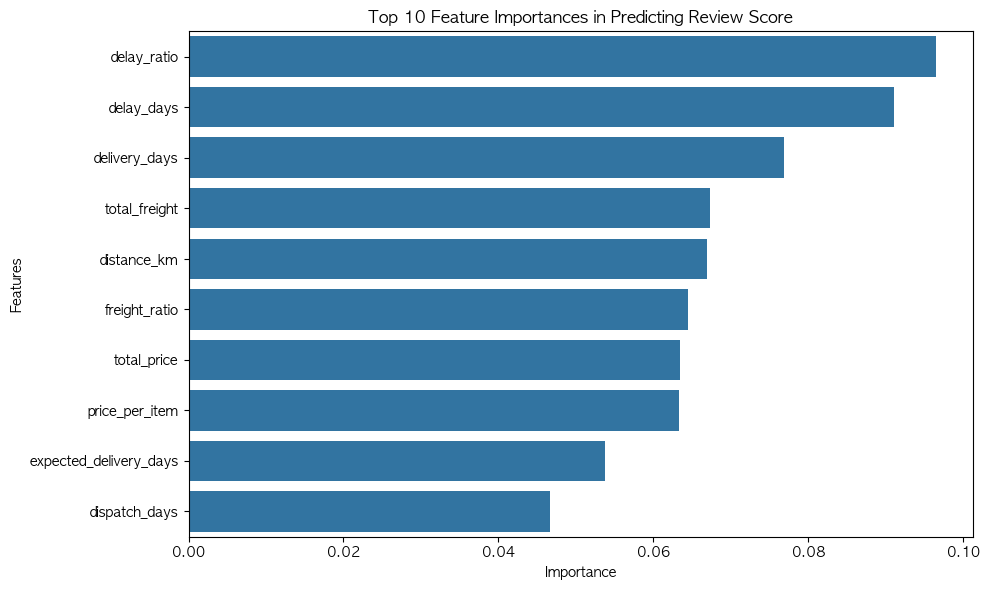

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 변수 선택 및 인코딩
features = ['total_items_count', 'delay_days', 'is_delayed', 
            'delivery_days', 'dispatch_days', 'approved_days', 'total_price', 'total_freight',
            'distance_km', 'expected_delivery_days', 'order_purchase_month', 'order_purchase_dayofweek',
            'main_category', 'freight_ratio', 'price_per_item', 'delay_ratio', 'route']

X = pd.get_dummies(df2[features], drop_first=True)

# 2. 타겟 변수 설정 (긍정 2, 보통 1, 부정 0)
def group_score(score):
    if score >= 4: return 2
    elif score == 3: return 1
    else: return 0
y = df2['review_score'].apply(group_score)

# 3. 데이터 분할
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.2, random_state=42)

# 4. 모델 학습 (두 코드의 장점 결합!)
rf_model = RandomForestClassifier(
    n_estimators=500,        
    max_depth=30,            
    min_samples_split=2,    # 과적합 방지 추가
    class_weight='balanced', # 클래스 불균형 해결
    n_jobs=-1,               # M4 Pro 코어 풀가동
    random_state=42
)

print("Random Forest 학습을 시작합니다...")
rf_model.fit(X_train, y_train)

# 5. 최종 평가
y_pred_rf = rf_model.predict(X_test)
print(f"\n[최종 테스트 세트 정확도]: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n[상세 리포트 - 0(부정)을 잘 맞추는지 확인!]\n", classification_report(y_test, y_pred_rf))

# ==========================================
# 6. ★ 배송 지연의 영향력 확인 (변수 중요도)
# ==========================================
# 모델이 예측할 때 어떤 변수를 가장 중요하게 봤는지 TOP 10을 뽑아봅니다.
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Top 10 Feature Importances in Predicting Review Score')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()